---
title: "Lab 2: Estadistica Descriptiva 1"
author: "Maximiliano Garnier Villarreal"
---

# Paquetes

In [ ]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import statistics
from scipy import stats
from statsmodels import robust

from plotnine.data import penguins

p9.theme_set(p9.theme_bw())

# Estadistica descriptiva

## Datos categoricos

### Tabla de frecuencias

La forma numerica de resumir datos categoricos es por medio de tablas de frecuencias (1 variable) o tablas de contingencia (2 variables). Para generar tablas de frecuencias en **Python** se puede usar `value_counts()` de **pandas** o `crosstab()` para tablas de contingencia.

In [3]:
tabla = penguins['species'].value_counts().reset_index(name='frecuencia')

tabla['frecuencia_cum'] = tabla['frecuencia'].cumsum()
tabla['porcentaje'] = (tabla['frecuencia'] / tabla['frecuencia'].sum()) * 100
tabla['porcentaje_cum'] = tabla['porcentaje'].cumsum()

tabla

,species,frecuencia,frecuencia_cum,porcentaje,porcentaje_cum
0,Adelie,152,152,44.186047,44.186047
1,Gentoo,124,276,36.046512,80.232558
2,Chinstrap,68,344,19.767442,100.000000


In [4]:
xtab = pd.crosstab(penguins['species'], 
                   penguins['island'], 
                   margins=True,
                   normalize=False # 'index', 'columns', 'all', False
                   )

xtab

island,Biscoe,Dream,Torgersen,All
species,,,,
Adelie,44,56,52,152
Chinstrap,0,68,0,68
Gentoo,124,0,0,124
All,168,124,52,344


### Graficos

#### Barras

Para `geom_bar` el argumento `position` puede tener cualquiera de estos tres valores: `stack`, `dodge` o `fill`, para cuando se visualizan 2 variables categoricas.

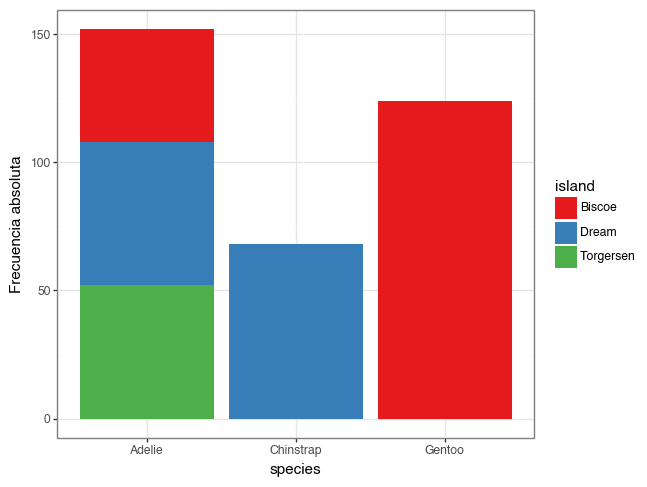

In [5]:
(p9.ggplot(penguins, p9.aes("species", fill = "island")) +
  p9.geom_bar() +
  p9.labs(y='Frecuencia absoluta') +
  p9.scale_fill_brewer(type='qual', palette='Set1'))

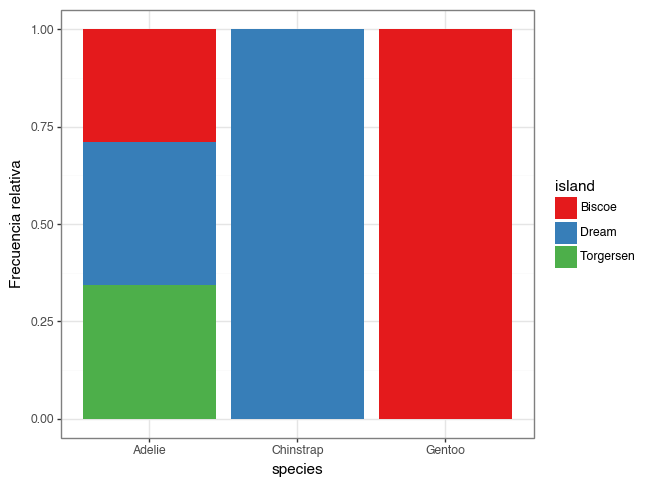

In [6]:
(p9.ggplot(penguins, p9.aes("species", fill = "island")) +
  p9.geom_bar(position = 'fill') +
  p9.labs(y='Frecuencia relativa') +
  p9.scale_fill_brewer(type='qual', palette='Set1'))

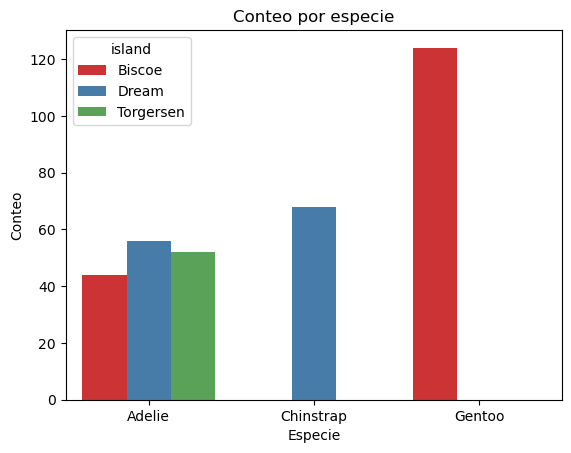

In [7]:
fig, ax = plt.subplots()
sns.countplot(data = penguins, x = "species", hue="island",
              dodge=True, 
              stat="count", # 'count','percent','probability','proportion'       
              palette = "Set1")
plt.xlabel("Especie")
plt.ylabel("Conteo")
plt.title("Conteo por especie")
plt.show()

## Datos continuos

### Tabla de Frecuencias

Para tablas de frecuencias con datos numericos estos deben ser separados en clases (*bins*) y sobre estas clases se genera la tabla de frecuencias. Se debe discretizar la variable, ya sea en clases definidas o numero de clases, sobre esta nueva variable se usa `value_counts()`.

In [8]:
series = pd.Series(penguins['flipper_length_mm'].dropna())
bins = np.arange(170, 240, 5) # rango y ancho de las clases
bins = 10 # numero de clases

binned_data = pd.cut(series, bins=bins, right=True, include_lowest=True)
tabla = binned_data.value_counts().sort_index()
tabla_df = tabla.to_frame(name='frecuencia')

tabla_df['frecuencia_cum'] = tabla_df['frecuencia'].cumsum()
tabla_df['porcentaje'] = (tabla_df['frecuencia'] / tabla_df['frecuencia'].sum()) * 100
tabla_df['porcentaje_cum'] = tabla_df['porcentaje'].cumsum()

tabla_df

,frecuencia,frecuencia_cum,porcentaje,porcentaje_cum
flipper_length_mm,,,,
"(171.94, 177.9]",3,3,0.877193,0.877193
"(177.9, 183.8]",22,25,6.432749,7.309942
"(183.8, 189.7]",52,77,15.204678,22.514620
"(189.7, 195.6]",79,156,23.099415,45.614035
"(195.6, 201.5]",44,200,12.865497,58.479532
"(201.5, 207.4]",15,215,4.385965,62.865497
"(207.4, 213.3]",42,257,12.280702,75.146199
"(213.3, 219.2]",42,299,12.280702,87.426901
"(219.2, 225.1]",28,327,8.187135,95.614035


### Graficos

#### Histograma

Dentro de `geom_histogram` hay 3 opciones para definir la discretizacion:

-   `bins` = Numero de clases
-   `binwidth` = El ancho de las clases
-   `breaks` = Un vector con los puntos donde separar los datos

Dentro de `sns.histplot` hay 2 opciones similares:
-   `bins` = Numero de clases o un vector con los puntos donde separar los datos
-   `binwidth` = El ancho de las clases

*Frecuencias absolutas*

/opt/miniconda3/envs/ds/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 2 rows containing non-finite values.


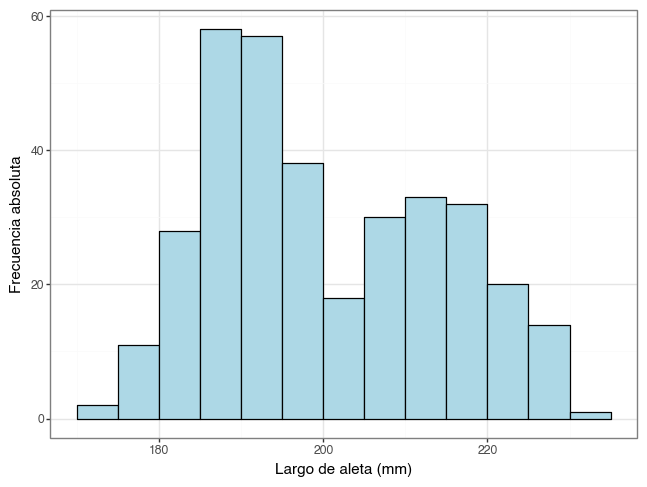

In [9]:
(p9.ggplot(penguins, p9.aes(x = "flipper_length_mm")) + 
  p9.geom_histogram(breaks = np.arange(170, 240, 5), 
                    color='black', fill='lightblue') +
  p9.labs(x='Largo de aleta (mm)', y='Frecuencia absoluta'))

In [ ]:
fig, ax = plt.subplots()
sns.histplot(data = penguins, x = "flipper_length_mm", 
             bins = np.arange(170, 240, 5), # puede ser el numero de bins tambien
             color = "blue", edgecolor = "black", kde=False)
plt.xlabel("Largo de aleta (mm)")
plt.ylabel("Frecuencia absoluta")
plt.title("Histograma de largo de aleta")
plt.show()

*Frecuencias relativas*

In [ ]:
(p9.ggplot(penguins, p9.aes(x = "flipper_length_mm",
                            y = p9.after_stat("count/sum(count)"))) + 
  p9.geom_histogram(breaks=np.arange(170, 240, 5),
                    color='black', fill='lightblue') +
  p9.labs(x='Largo de aleta (mm)', y='Frecuencia relativa'))

In [ ]:
fig, ax = plt.subplots()
sns.histplot(data = penguins, x = "flipper_length_mm", 
             bins = np.arange(170, 240, 5), # puede ser el numero de bins tambien
             color = "blue", edgecolor = "black", 
             kde=False, stat="probability")
plt.xlabel("Largo de aleta (mm)")
plt.ylabel("Frecuencia relativa")
plt.title("Histograma de largo de aleta")
plt.show()

#### Grafico de caja

In [ ]:
(p9.ggplot(penguins, p9.aes(x = "species", y = "bill_length_mm")) +
  p9.geom_boxplot())

In [ ]:
(p9.ggplot(penguins, p9.aes(x = "species", y = "bill_length_mm")) +
  p9.geom_boxplot() +
  p9.stat_summary(fun_y = np.mean, geom = "point", 
                  color = "red", size = 5, shape = "+") +
  p9.labs(x='Especie', y='Largo del pico (mm)',
          title='Boxplot de largo del pico por especie'))

In [ ]:
fig, ax = plt.subplots()
sns.boxplot(data = penguins, x = "species", y = "bill_length_mm", 
            palette = "Set2")
plt.xlabel("Especie")
plt.ylabel("Largo del pico (mm)")
plt.title("Boxplot de largo del pico por especie")
plt.show()

### Medidas de tendencia central

Se muestran diferentes funciones para caracterizar la tendencia central en un vector corriente, uno con un valor atipico y otro con un valor faltante, para ver como se ven afectadas las diferentes estadisticas. En general se usan funciones de **numpy**, **pandas**, **statistics** y **scipy.stats**.

In [11]:
myvector = np.array([22,10,10,16,15,15,24,19,15,19,18,16,18,12,17,17,11,18], dtype=float)
myseries = pd.Series(myvector)

print(np.mean(myvector))

16.22222222222222


In [12]:
print(statistics.median(myvector))

16.5


In [ ]:
print(stats.gmean(myvector)) # media geometrica

In [ ]:
print(statistics.geometric_mean(myvector)) # media geometrica

In [ ]:
outlier = np.append(myvector,200)

print(np.mean(outlier))
print(statistics.median(outlier))
print(stats.gmean(outlier)) # media geometrica

In [ ]:
miss = np.append(myvector,np.nan)

print(np.nanmean(miss))

In [ ]:
print(statistics.median(miss))

In [ ]:
print(stats.gmean(miss[~np.isnan(miss)])) # media geometrica sin NaN

### Medidas de dispersion

In [ ]:
print(np.var(myvector, ddof=1)) # varianza muestral

In [ ]:
print(np.std(myvector, ddof=1)) # desviacion estandar muestral

In [ ]:
print(myseries.var()) # varianza muestral

In [ ]:
print(myseries.std() )# desviacion estandar muestral

In [ ]:
print(statistics.variance(myvector)) # varianza muestral

In [ ]:
print(statistics.stdev(myvector)) # desviacion estandar muestral

In [ ]:
print(stats.iqr(myvector)) # rango intercuartil

In [ ]:
print(robust.mad(myvector, center=np.median(myvector))) # desviacion absoluta de la mediana

In [ ]:
cv = (myseries.std() / myseries.mean()) * 100 # coeficiente de variacion
print(cv)

Con valor atipico

In [ ]:
print(np.std(outlier, ddof=1)) # desviacion estandar muestral

In [ ]:
print(robust.mad(outlier, center=np.median(outlier))) # desviacion absoluta de la mediana

### Asimetria y Curtosis

In [ ]:
print(stats.kurtosis(myvector))

In [ ]:
print(stats.skew(myvector))

### Descripciones mas generales

Se muestran varias funciones que generan un resumen general de un vector o DataFrame.

#### Vector

In [ ]:
myseries.describe()

#### DataFrame

In [ ]:
penguins.describe()